In [ ]:
# TO DO also: 
# check data loader for final number of partitions (force it to be what specified instead of always half??) ?;
# ---> try with "old" kmeans?? ---> DEBUG NEW KMEANS (check matrices stuff)?

# modify run_benchmark to avoid repartitioning, and avoid re-downloading dask bag?? (consider using run_worker_sweep for simplicity??)
# clean up code (image saving, etc)?
# re-run final, clean code?

# K-means|| distribuito su Dask — Analisi

Notebook di orchestrazione: avvia il cluster, carica il dataset, esegue i test (singola run o benchmark su più combinazioni) e salva i risultati in `./results`.

Moduli usati:
- `kmeans_parallel.py` — algoritmo k-means|| distribuito
- `launch_cluster.py` — avvio/spegnimento del cluster Dask via SSH
- `data_loader.py` — caricamento del dataset
- `benchmark.py` — esecuzione dei test e salvataggio risultati

#### Useful: to kill existing Dask processes (from bash):
```bash
for ip in 10.67.22.194 10.67.22.254 10.67.22.34 10.67.22.145 10.67.22.121 10.67.22.192 10.67.22.18 10.67.22.187 10.67.22.48; do
    echo "Killing on $ip..."
    ssh -o StrictHostKeyChecking=no ubuntu@"$ip" "pkill -9 -f dask-scheduler; pkill -9 -f dask-worker; pkill -9 -f dask_ssh" 
done
```

## 1. Import

In [1]:
import numpy as np
import pandas as pd
from src.kmeans_parallel import kmeans_parallel
from src.launch_cluster import launch_cluster, shutdown_cluster
from src.data_loader import load_dataset
from src.benchmark import run_single_test, run_benchmark, calculate_inertia, combinations_fn

import time

## 2. Parametri configurabili

Modifica qui i valori per cambiare numero di worker, `k`, `l` (oversampling factor) e `r` (numero di round dell'inizializzazione parallela).

In [2]:
# --- Cluster ---
N_WORKERS = 8      # tra 1 e 8 (nodi disponibili in launch_cluster.py)
NUM_PARTITIONS = 8 * N_WORKERS   # regola empirica: >= n_threads_per_worker * n_workers

In [3]:
# --- Algoritmo k-means|| ---
#K = 500                # numero di cluster finali
#L = 250                # oversampling factor (assoluto). In alternativa: L = round(L_OVER_K * K)
#R = 10                  # numero di round dell'inizializzazione parallela
#MAX_ITER_FIT = 100      # iterazioni massime della fase di Lloyd's (fit)

SEED = 42

In [4]:
# --- Dataset ---
DATASET_URL_10PC = "https://ndownloader.figshare.com/files/5976042"
# link used by sklearn function fetch_kddcup99 (original link gives 403 error)
#***for 10% dataset***

DATASET_URL_FULL="https://ndownloader.figshare.com/files/5976045"
#***FULL DATASET***

RAW_GZ_PATH_10PC   = "/home/ubuntu/Project/libero_development/data/kddcup_data.gz" # compressed (.gz) dataset file
PARQUET_PATH_10PC = '/tmp/kddcup_data.parquet' # single Parquet file (ie a compressed format file but partition-able, unlike .gz) on master

RAW_GZ_PATH_FULL = "/home/ubuntu/backup/libero_development/data/kddcup_data_full.gz"
PARQUET_PATH_FULL = '/tmp/kddcup_data_full.parquet'

# column names of KDD dataset, from source code of the above sklearn function;
# "protocol_type","service","flag" are non-numeric so they will be dropped later,
# as will be "label" and the constant column 'num_outbound_cmds' 
# (10% dataset might have more constant columns such as 'is_host_login')
COL_NAMES = [
    "duration","protocol_type","service","flag","src_bytes",
    "dst_bytes","land","wrong_fragment","urgent","hot",
    "num_failed_logins","logged_in","num_compromised","root_shell",
    "su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate",
    "dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate",
    "dst_host_srv_rerror_rate","label"
]

## 3. Start cluster

In [5]:
# DO NOT RUN if already existing!
cluster, client = launch_cluster(N_WORKERS)

Inizializzazione del cluster SSH con 8 worker...
Worker selezionati: ['10.67.22.254', '10.67.22.34', '10.67.22.145', '10.67.22.121', '10.67.22.192', '10.67.22.18', '10.67.22.187', '10.67.22.48']


2026-08-27 11:00:05,007 - distributed.deploy.ssh - INFO - 2026-08-27 11:00:05,006 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-08-27 11:00:05,034 - distributed.deploy.ssh - INFO - 2026-08-27 11:00:05,034 - distributed.scheduler - INFO - State start
2026-08-27 11:00:05,037 - distributed.deploy.ssh - INFO - 2026-08-27 11:00:05,037 - distributed.scheduler - INFO -   Scheduler at:   tcp://10.67.22.194:8786
2026-08-27 11:00:06,764 - distributed.deploy.ssh - INFO - 2026-08-27 11:00:06,764 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.18:44793'
2026-08-27 11:00:06,771 - distributed.deploy.ssh - INFO - 2026-08-27 11:00:06,769 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.254:39197'
2026-08-27 11:00:06,776 - distributed.deploy.ssh - INFO - 2026-08-27 11:00:06,773 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.121

Cluster avviato e connessione stabilita con successo!



#### Connect to cluster IF INSTEAD already exsiting:

In [ ]:
from dask.distributed import Client

SCHEDULER_ADDRESS = "tcp://10.67.22.194:8786"

try:
    client = Client(SCHEDULER_ADDRESS, timeout="10s")
    print("Connected to cluster successfully!")
    print(f"Dask Dashboard link: {client.dashboard_link}")

except Exception as e:
    print(f"Connection error: {e}")

In [7]:
client.scheduler_info()

{'type': 'Scheduler',
 'id': 'Scheduler-7b3fad01-9d51-4288-b5b8-446d1136bee3',
 'address': 'tcp://10.67.22.194:8786',
 'services': {'dashboard': 8787},
 'started': 1787818915.6491818,
 'n_workers': 8,
 'total_threads': 64,
 'total_memory': 66574651392,
 'workers': {'tcp://10.67.22.121:34775': {'type': 'Worker',
   'id': 'tcp://10.67.22.121:34775',
   'host': '10.67.22.121',
   'resources': {},
   'local_directory': '/tmp/dask-scratch-space/worker-b7komqk7',
   'name': 'tcp://10.67.22.121:34775',
   'nthreads': 8,
   'memory_limit': 8321835008,
   'last_seen': 1787818941.0081604,
   'services': {'dashboard': 40803},
   'metrics': {'task_counts': {},
    'bandwidth': {'total': 100000000, 'workers': {}, 'types': {}},
    'digests_total_since_heartbeat': {'tick-duration': 0.4997410774230957,
     'latency': 0.0016012191772460938},
    'managed_bytes': 0,
    'spilled_bytes': {'memory': 0, 'disk': 0},
    'transfer': {'incoming_bytes': 0,
     'incoming_count': 0,
     'incoming_count_total': 0,
     'outgoing_bytes': 0,
     'outgoing_count': 0,
     'outgoing_count_total': 0},
    'event_loop_interval': 0.019981460571289064,
    'cpu': 2.0,
    'memory': 61329408,
    'time': 1787818940.5070992,
    'host_net_io': {'read_bps': 523.8797694702522,
     'write_bps': 1539.6466507331838},
    'host_disk_io': {'read_bps': 0.0, 'write_bps': 0.0},
    'num_fds': 21},
   'status': 'running',
   'nanny': 'tcp://10.67.22.121:33191'},
  'tcp://10.67.22.145:46117': {'type': 'Worker',
   'id': 'tcp://10.67.22.145:46117',
   'host': '10.67.22.145',
   'resources': {},
   'local_directory': '/tmp/dask-scratch-space/worker-hs7g630f',
   'name': 'tcp://10.67.22.145:46117',
   'nthreads': 8,
   'memory_limit': 8321835008,
   'last_seen': 1787818941.0517302,
   'services': {'dashboard': 36955},
   'metrics': {'task_counts': {},
    'bandwidth': {'total': 100000000, 'workers': {}, 'types': {}},
    'digests_total_since_heartbeat': {'tick-duration': 0.4990105628967285,
     'latency': 0.001688241958618164},
    'managed_bytes': 0,
    'spilled_bytes': {'memory': 0, 'disk': 0},
    'transfer': {'incoming_bytes': 0,
     'incoming_count': 0,
     'incoming_count_total': 0,
     'outgoing_bytes': 0,
     'outgoing_count': 0,
     'outgoing_count_total': 0},
    'event_loop_interval': 0.020019946098327638,
    'cpu': 2.0,
    'memory': 61935616,
    'time': 1787818940.5507274,
    'host_net_io': {'read_bps': 262.18739722890604,
     'write_bps': 1433.0242474495933},
    'host_disk_io': {'read_bps': 0.0, 'write_bps': 0.0},
    'num_fds': 21},
   'status': 'running',
   'nanny': 'tcp://10.67.22.145:46455'},
  'tcp://10.67.22.187:38949': {'type': 'Worker',
   'id': 'tcp://10.67.22.187:38949',
   'host': '10.67.22.187',
   'resources': {},
   'local_directory': '/tmp/dask-scratch-space/worker-1rcfpqin',
   'name': 'tcp://10.67.22.187:38949',
   'nthreads': 8,
   'memory_limit': 8321822720,
   'last_seen': 1787818941.281503,
   'services': {'dashboard': 45427},
   'metrics': {'task_counts': {},
    'bandwidth': {'total': 100000000, 'workers': {}, 'types': {}},
    'digests_total_since_heartbeat': {'tick-duration': 0.5005800724029541,
     'latency': 0.0036783218383789062},
    'managed_bytes': 0,
    'spilled_bytes': {'memory': 0, 'disk': 0},
    'transfer': {'incoming_bytes': 0,
     'incoming_count': 0,
     'incoming_count_total': 0,
     'outgoing_bytes': 0,
     'outgoing_count': 0,
     'outgoing_count_total': 0},
    'event_loop_interval': 0.02000070095062256,
    'cpu': 2.0,
    'memory': 61489152,
    'time': 1787818940.7804375,
    'host_net_io': {'read_bps': 261.3254583051865,
     'write_bps': 1428.3131919581185},
    'host_disk_io': {'read_bps': 0.0, 'write_bps': 0.0},
    'num_fds': 21},
   'status': 'running',
   'nanny': 'tcp://10.67.22.187:40819'},
  'tcp://10.67.22.18:35919': {'type': 'Worker',
   'id': 'tcp://10.67.22.18:35919',
   'host': '10.67.22.18',
   'resources': {},
   'local_directory': '/tmp/dask-scratch-space/worker-6_l_uako',
   

## 4. Load dataset

In [6]:
#10 percent:

start=time.time()
X_bag_10_percent, (mean_ar, std_ar)=load_dataset(n_partitions=NUM_PARTITIONS,
                   client=client,
                   dataset_url=DATASET_URL_10PC,
                   raw_gz_path=RAW_GZ_PATH_10PC,
                   parquet_path=PARQUET_PATH_10PC,
                   parquet_path_workers=PARQUET_PATH_10PC,
                   col_names=COL_NAMES,
                   force_download=False)
end=time.time()
elapsed=end-start
print(f"Time elapsed: {elapsed:.2f} s")

Converting .gz -> Parquet chunk sizes...
Parquet file created (compressed with snappy).
Number of partitions before preprocessing: 64
Constant columns: ['num_outbound_cmds', 'is_host_login']
Computing global mean and std (first pass over data)...
Distributed bag created with 32 partitions.
Number of samples: 494021
Time elapsed: 11.96 s


In [ ]:
# if want to go back to original coordinates later:
#print(mean_ar, '\n\n\n') 
#print(std_ar)

In [21]:
# full:

start=time.time()
X_bag_full, (mean_ar, std_ar)=load_dataset(n_partitions=NUM_PARTITIONS,
                   client=client,
                   dataset_url=DATASET_URL_FULL,#DATASET_URL_10PC,
                   raw_gz_path=RAW_GZ_PATH_FULL,#RAW_GZ_PATH,
                   parquet_path=PARQUET_PATH_FULL,#PARQUET_PATH,
                   parquet_path_workers=PARQUET_PATH_FULL,#PARQUET_PATH,
                   col_names=COL_NAMES,
                   force_download=True)
end=time.time()
elapsed=end-start
print(f"Time elapsed: {elapsed:.2f} s")

Converting .gz -> Parquet chunk sizes...
Parquet file created (compressed with snappy).
Number of partitions before preprocessing: 64
Constant columns: ['num_outbound_cmds']
Computing global mean and std (first pass over data)...
Distributed bag created with 32 partitions.
Number of samples: 4898431
Time elapsed: 61.41 s


#### Check that loaded correctly

In [ ]:
# this was done earlier, for full dataset:

In [34]:
# global variable used in data_loader.py 
print(f"Number of initial features (should be 42): {len(COL_NAMES)}")

Number of initial features (should be 42): 42


In [35]:
lengths = X_bag_full.map(len).frequencies().compute() # length of every row- its unnormalized PMF
print("Feature count distribution (should be 37 for full dataset, see below):", lengths)
# Should show one unique length, 37 (see below)

Feature count distribution (should be 37 for full dataset, see below): [(37, 4898431)]


In [36]:
n_points = X_bag_full.count().compute()
n_features = X_bag_full.map(len).take(1)[0] # since all rows have same length
print(f"Points: {n_points}, Features: {n_features}\n(Full dataset should contain 4898431 samples with 37 (=42 -1 label -3 non numeric -1 constant feature) numerical, non-constant features)")

Points: 4898431, Features: 37
(Full dataset should contain 4898431 samples with 37 (=42 -1 label -3 non numeric -1 constant feature) numerical, non-constant features)


In [37]:
has_nan = X_bag_full.map(lambda x: np.isnan(x).any()).any().compute()
has_inf = X_bag_full.map(lambda x: np.isinf(x).any()).any().compute()
print(f"Has NaN: {has_nan}, Has Inf: {has_inf}\n(Both must be False)")

Has NaN: False, Has Inf: False
(Both must be False)


In [39]:
total = X_bag_full.reduction(
    lambda part: np.sum(np.vstack(list(part)), axis=0),
    lambda parts: np.sum(list(parts), axis=0)
).compute()
mean = total / n_points
means_vector=np.any(np.abs(mean)>1e-3)
print(f"Any column mean significantly different from zero: {means_vector==True}\n(Must be False)")

Any column mean significantly different from zero: False
(Must be False)


In [40]:
sq_total = X_bag_full.reduction(
    lambda part: np.sum(np.vstack(list(part))**2, axis=0),
    lambda parts: np.sum(list(parts), axis=0)
).compute()

std = np.sqrt(sq_total / n_points - mean**2)
std_minus_one_vector=np.abs(std - 1)
print(f"Any column where std significantly different from one: {np.any(std_minus_one_vector > 1e-3)}\n(Must be False)")

Any column where std significantly different from one: False
(Must be False)


In [41]:
sample_rows = X_bag_full.take(3)
for i, row in enumerate(sample_rows):
    print(f"Row {i}: shape={row.shape}, first 5 values={row[:5]}")

Row 0: shape=(37,), first 5 values=[-0.06683318 -0.00172038  0.06818843 -0.00239085 -0.01513917]
Row 1: shape=(37,), first 5 values=[-0.06683318 -0.00177668  0.00532451 -0.00239085 -0.01513917]
Row 2: shape=(37,), first 5 values=[-0.06683318 -0.00169808  0.00020833 -0.00239085 -0.01513917]


In [42]:
# additional sanity check
print("Type of X_bag_full:", type(X_bag_full))
print("Number of partitions:", X_bag.npartitions)

Type of X_bag: <class 'dask.bag.core.Bag'>
Number of partitions: 32


In [43]:
sizes = X_bag_full.map_partitions(lambda block: block.nbytes)
total_bytes = sum(sizes.compute())
print(f"Total bag size: {total_bytes / 1e6:.2f} MB")

exp_size=n_features * n_points * 8
print(f"Expected size: {exp_size / 1e6} MB")

Total bag size: 1449.94 MB
Expected size: 1449.935576 MB


## 5. Single run

Runs a single combination of parameters (the ones defined in section 2) and prints the cost and execution time.

In [9]:
K = 500                # numero di cluster finali
L = 250                # oversampling factor (assoluto). In alternativa: L = round(L_OVER_K * K)
R = 10                  # numero di round dell'inizializzazione parallela
MAX_ITER_FIT = 10      # iterazioni massime della fase di Lloyd's (fit)

dataset_bag=X_bag_10_percent
# consider other values?? eg in original paper, or K=23 for real life dataset

In [10]:
# consider other values?? eg in original paper, or K=23 for real life dataset

start=time.time()
result, _ = run_single_test(
    client,
    k=K, l=L, r=R,
    num_partitions=NUM_PARTITIONS*2,
    max_iter_fit=MAX_ITER_FIT,
    seed=SEED,
    X_bag=X_bag_10_percent,
    track_convergence=True,
    track_centroids=True
)
result
end=time.time()
elapsed=end-start
print(f"Time elapsed: {elapsed:.2f} s")

 -> Final cost: 54257.32 | Time: 28.09s
Time elapsed: 31.93 s


In [ ]:
# 29 s WITHOUT tracking anything

In [11]:
#cost =567232.43 
#cost_ten=cost * 1e-10
#print(f"(Cost equivalent to {cost_ten :.2f} * 10^10)")
minutes=elapsed/60
print(f"(Time elapsed equivalent to {minutes:.2f} minutes)")

(Time elapsed equivalent to 0.53 minutes)


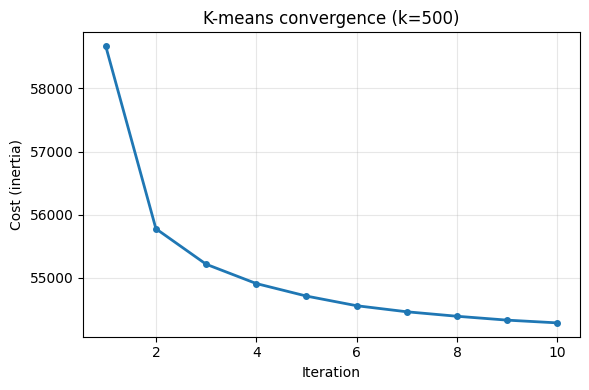

In [12]:
# if tracked cost:

import matplotlib.pyplot as plt

iterations = range(1, len(result["cost_history"]) + 1)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(iterations, result["cost_history"], marker="o", markersize=4, linewidth=2, color="tab:blue")
ax.set_xlabel("Iteration")
ax.set_ylabel("Cost (inertia)")
ax.set_title(f"K-means convergence (k={result['k']})")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

In [13]:
centroids_table = pd.DataFrame({
    "round": range(1, len(result["n_centroids_history"]) + 1),
    "n_centroids": result["n_centroids_history"],
})
centroids_table.style.set_caption(f"l = {result['l']}")

,round,n_centroids
0,1,217
1,2,447
2,3,691
3,4,930
4,5,1199
5,6,1441
6,7,1721
7,8,1961
8,9,2230
9,10,2476


Compare with:
* Cost $19 \cdot 10^{10}$ ($k=500$, $l=0.5 k$, but $r=5$ instead - table 3.).
  HOWEVER, note that here we standardized data beforehand!
* Running time $69.0 \text{ min}$ for the same values (table 4)

In [ ]:
# check if cost computed differently??

## 6. Multi-combination benchmark

Testa più combinazioni di `(n_workers, partitions, l_over_k, r)` per diversi valori di `k`, e salva tutto in `./results`. 

**Nota:** il numero di worker effettivamente attivi nel cluster è quello impostato con `launch_cluster` in sezione 3 — la colonna `workers` qui sotto serve solo per etichettare/loggare i risultati, non riavvia il cluster.

### Varying number of workers

#### On 10% dataset

In [ ]:
# write as function? but this is clearer and not that long

In [7]:
# as best combination (for cost) in figure 5.1 in original paper:

R = 5 

l_over_k = 4

K_VALUES=[129]

MAX_ITER_FIT=10 # unimportant to get perfect convergence,
                # as we're investigating only ideal number of workers (wrt to computation time)

In [8]:
n_workers=[2,4,6,8]

avg_iters=3

In [9]:
shutdown_cluster(cluster,client)

Cluster e client chiusi.


In [ ]:
frames = []
for n in n_workers:
    cluster, client = launch_cluster(n)
    X_bag_10_percent, _ = load_dataset(n_partitions=8*n,
                   client=client,
                   dataset_url=DATASET_URL_10PC,
                   raw_gz_path=RAW_GZ_PATH_10PC,
                   parquet_path=PARQUET_PATH_10PC,
                   parquet_path_workers=PARQUET_PATH_10PC,
                   col_names=COL_NAMES,
                   force_download=False)  # rebuild bag on new client - perhaps unnenecessary??
    
    df_n = run_benchmark(client, X_bag=X_bag_10_percent,
                         combinations=combinations_fn(n_workers=n,l_over_k=l_over_k,r=R),
                         # function assigning appropriate values (in particular n partitions = 8 * n workers)
                         k_values=K_VALUES, label=f"{n}_workers_10_percent", 
                         max_iter_fit=MAX_ITER_FIT, seed=SEED,
                         averaging_iterations=avg_iters)
    
    df_n["num_workers"] = n
    frames.append(df_n)
    shutdown_cluster(cluster, client)

df_all = pd.concat(frames, ignore_index=True)

In [32]:
import os
RESULTS_DIR = "/home/ubuntu/Project/libero_development/results"
FIGURES_DIR= "/home/ubuntu/Project/libero_development/figures"
os.makedirs(RESULTS_DIR, exist_ok=True)
csv_path = os.path.join(RESULTS_DIR, f"worker_sweep_{time.strftime('%Y%m%d%H%M%S')}_10pc.csv")
figure_path=os.path.join(FIGURES_DIR, f"worker_sweep_{time.strftime('%Y%m%d%H%M%S')}_10pc.png")
df_all.to_csv(csv_path, index=False)
print(f"Saved to: {csv_path}")

Saved to: /home/ubuntu/Project/libero_development/results/worker_sweep_20260827115917_10pc.csv


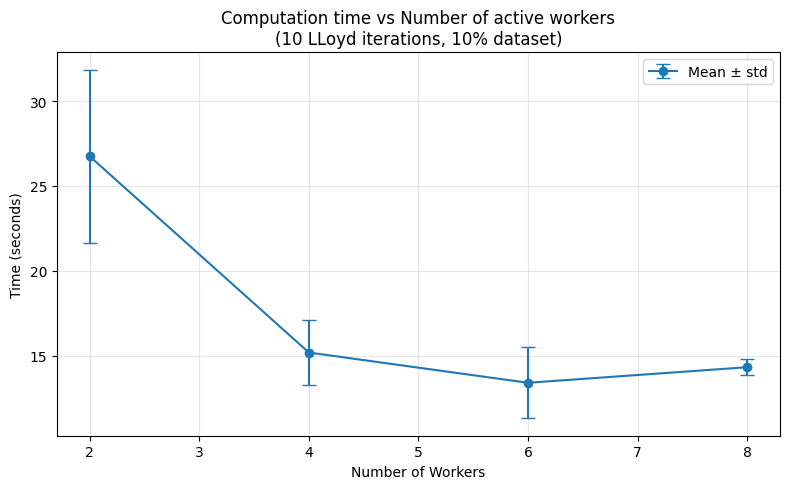

In [33]:
# Group by number of workers, compute mean and std of time
stats = df_all.groupby("num_workers")["time"].agg(["mean", "std"]).reset_index()

plt.figure(figsize=(8, 5))
plt.errorbar(
    stats["num_workers"], 
    stats["mean"], 
    yerr=stats["std"], 
    marker="o", 
    capsize=5,
    linestyle="-",
    label="Mean ± std"
)
plt.xlabel("Number of Workers")
plt.ylabel("Time (seconds)")
plt.title("Computation time vs Number of active workers\n(10 LLoyd iterations, 10% dataset)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(figure_path, dpi=150)
plt.show()

In [24]:
# and, can check directly to see that similar final cost for any number of workers

#### On full dataset

In [34]:
n_workers=[4,5,6,7,8]

avg_iters=3

In [29]:
# other params same as above

In [35]:
shutdown_cluster(cluster,client)

Cluster e client chiusi.


In [36]:
frames = []
for n in n_workers:
    cluster, client = launch_cluster(n)
    X_bag_full, _ = load_dataset(n_partitions=8*n,
                   client=client,
                   dataset_url=DATASET_URL_FULL,
                   raw_gz_path=RAW_GZ_PATH_FULL,
                   parquet_path=PARQUET_PATH_FULL,
                   parquet_path_workers=PARQUET_PATH_FULL,
                   col_names=COL_NAMES,
                   force_download=False)  # rebuild bag on new client
    
    df_n = run_benchmark(client, X_bag=X_bag_full,
                         combinations=combinations_fn(n_workers=n,l_over_k=l_over_k,r=R),
                         # function assigning appropriate values (in particular n partitions = 8 * n workers)
                         k_values=K_VALUES, label=f"{n}_workers_full", 
                         max_iter_fit=MAX_ITER_FIT, seed=SEED,
                         averaging_iterations=avg_iters)
    
    df_n["num_workers"] = n
    frames.append(df_n)
    shutdown_cluster(cluster, client)

df_all = pd.concat(frames, ignore_index=True)

Inizializzazione del cluster SSH con 4 worker...
Worker selezionati: ['10.67.22.254', '10.67.22.34', '10.67.22.145', '10.67.22.121']


2026-08-27 12:00:16,609 - distributed.deploy.ssh - INFO - 2026-08-27 12:00:16,608 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-08-27 12:00:16,637 - distributed.deploy.ssh - INFO - 2026-08-27 12:00:16,637 - distributed.scheduler - INFO - State start
2026-08-27 12:00:16,641 - distributed.deploy.ssh - INFO - 2026-08-27 12:00:16,641 - distributed.scheduler - INFO -   Scheduler at:   tcp://10.67.22.194:8786
2026-08-27 12:00:17,829 - distributed.deploy.ssh - INFO - 2026-08-27 12:00:17,827 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.254:40377'
2026-08-27 12:00:17,835 - distributed.deploy.ssh - INFO - 2026-08-27 12:00:17,835 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.121:43771'
2026-08-27 12:00:17,838 - distributed.deploy.ssh - INFO - 2026-08-27 12:00:17,834 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.14

Cluster avviato e connessione stabilita con successo!

Using cached dataset: /home/ubuntu/backup/libero_development/data/kddcup_data_full.gz
Converting .gz -> Parquet chunk sizes...
Parquet file created (compressed with snappy).
Number of partitions before preprocessing: 32
Constant columns: ['num_outbound_cmds']
Computing global mean and std (first pass over data)...
Distributed bag created with 16 partitions.
Number of samples: 4898431
Testing: k=129, workers=4, partitions=32, l=516 (l/k=4), r=5
 Iterating 3 times.
Iteration 0


KilledWorker: Attempted to run task '_update_state-6ee8557a-41be-40aa-b21e-83f29e7da2d0' on 4 different workers, but all those workers died while running it. The last worker that attempt to run the task was tcp://10.67.22.254:35899. Inspecting worker logs is often a good next step to diagnose what went wrong. For more information see https://distributed.dask.org/en/stable/killed.html.

In [ ]:
csv_path = os.path.join(RESULTS_DIR, f"worker_sweep_{time.strftime('%Y%m%d%H%M%S')}_full.csv")
figure_path=os.path.join(FIGURES_DIR, f"worker_sweep_{time.strftime('%Y%m%d%H%M%S')}_full.png")
df_all.to_csv(csv_path, index=False)
print(f"Saved to: {csv_path}")

In [ ]:
# Group by number of workers, compute mean and std of time
stats = df_all.groupby("num_workers")["time"].agg(["mean", "std"]).reset_index()

plt.figure(figsize=(8, 5))
plt.errorbar(
    stats["num_workers"], 
    stats["mean"], 
    yerr=stats["std"], 
    marker="o", 
    capsize=5,
    linestyle="-",
    label="Mean ± std"
)
plt.xlabel("Number of Workers")
plt.ylabel("Time (seconds)")
plt.title("Computation time vs Number of active workers\n(10 LLoyd iterations, full dataset)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(figure_path, dpi=150)
plt.show()

### Varying number of partitions

#### On 10% dataset

In [ ]:
dataset_bag= X_bag_10_percent
avg_iters=10

In [15]:
# other params same as above

In [16]:
combos = [                      
    (N_WORKERS, 32, l_over_k, R),   # under-partitioned
    (N_WORKERS, 64, l_over_k, R),   # balanced (1 part/thread)
    #(N_WORKERS, 65, l_over_k, R),   # imbalanced
    (N_WORKERS, 128, l_over_k, R),  # over-partitioned
]

In [17]:
df = run_benchmark(client, X_bag=dataset_bag, combinations=combos,
                   k_values=K_VALUES, label="num_partitions_10_percent",
                   max_iter_fit=MAX_ITER_FIT, seed=SEED, averaging_iterations=avg_iters)

Testing: k=129, workers=8, partitions=32, l=516 (l/k=4), r=5
 Iterating 10 times.
Iteration 0
 -> Final cost: 205750.72 | Time: 14.97s
Iteration 1
 -> Final cost: 202106.71 | Time: 13.20s
Iteration 2
 -> Final cost: 203365.50 | Time: 11.99s
Iteration 3
 -> Final cost: 201821.74 | Time: 12.31s
Iteration 4
 -> Final cost: 199675.23 | Time: 13.43s
Iteration 5
 -> Final cost: 205893.35 | Time: 14.96s
Iteration 6
 -> Final cost: 196790.38 | Time: 12.31s
Iteration 7
 -> Final cost: 199653.08 | Time: 13.99s
Iteration 8
 -> Final cost: 207573.62 | Time: 12.55s
Iteration 9
 -> Final cost: 202130.22 | Time: 14.75s
Testing: k=129, workers=8, partitions=64, l=516 (l/k=4), r=5
 Iterating 10 times.
Iteration 0
 -> Final cost: 199493.32 | Time: 14.52s
Iteration 1
 -> Final cost: 198606.40 | Time: 15.41s
Iteration 2
 -> Final cost: 203570.77 | Time: 15.58s
Iteration 3
 -> Final cost: 197678.16 | Time: 14.38s
Iteration 4
 -> Final cost: 201172.59 | Time: 14.62s
Iteration 5
 -> Final cost: 203836.11 | T

KeyError: 'cost'

In [ ]:
df

#### On full dataset

In [ ]:
# IMPORTANT NOTE: for sure comparison, at this point, we shut down and recreate cluster:

In [26]:
shutdown_cluster(cluster,client)

Cluster e client chiusi.


In [27]:
cluster, client= launch_cluster(N_WORKERS)

Inizializzazione del cluster SSH con 8 worker...
Worker selezionati: ['10.67.22.254', '10.67.22.34', '10.67.22.145', '10.67.22.121', '10.67.22.192', '10.67.22.18', '10.67.22.187', '10.67.22.48']


2026-08-27 09:17:35,766 - distributed.deploy.ssh - INFO - 2026-08-27 09:17:35,765 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-08-27 09:17:35,793 - distributed.deploy.ssh - INFO - 2026-08-27 09:17:35,793 - distributed.scheduler - INFO - State start
2026-08-27 09:17:35,797 - distributed.deploy.ssh - INFO - 2026-08-27 09:17:35,797 - distributed.scheduler - INFO -   Scheduler at:   tcp://10.67.22.194:8786
2026-08-27 09:17:37,377 - distributed.deploy.ssh - INFO - 2026-08-27 09:17:37,378 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.48:43661'
2026-08-27 09:17:37,385 - distributed.deploy.ssh - INFO - 2026-08-27 09:17:37,387 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.18:38491'
2026-08-27 09:17:37,395 - distributed.deploy.ssh - INFO - 2026-08-27 09:17:37,395 - distributed.nanny - INFO -         Start Nanny at: 'tcp://10.67.22.254:

Cluster avviato e connessione stabilita con successo!



In [22]:
# as best combination (for cost) in figure 5.1 in original paper:

dataset_bag= X_bag_full
avg_iters=3 # for faster results (small stdev anyways)

In [23]:
# other params same as above

In [24]:
df = run_benchmark(client, X_bag=dataset_bag, combinations=combos,
                   k_values=K_VALUES, label="num_partitions_full",
                   max_iter_fit=MAX_ITER_FIT, seed=SEED, averaging_iterations=avg_iters)

Testing: k=129, workers=8, partitions=32, l=516 (l/k=4), r=5
 Iterating 3 times.
Iteration 0
 -> Final cost: 2276187.60 | Time: 90.53s
Iteration 1
 -> Final cost: 2184723.35 | Time: 89.21s
Iteration 2
 -> Final cost: 2200839.67 | Time: 91.10s
Testing: k=129, workers=8, partitions=64, l=516 (l/k=4), r=5
 Iterating 3 times.
Iteration 0
 -> Final cost: 2180532.70 | Time: 74.25s
Iteration 1
 -> Final cost: 2211188.62 | Time: 73.15s
Iteration 2
 -> Final cost: 2171423.86 | Time: 72.28s
Testing: k=129, workers=8, partitions=128, l=516 (l/k=4), r=5
 Iterating 3 times.
Iteration 0
 -> Final cost: 2194203.12 | Time: 79.11s
Iteration 1
 -> Final cost: 2198823.13 | Time: 83.91s
Iteration 2
 -> Final cost: 2208590.30 | Time: 80.84s

Risultati completi salvati in: ../results/num_partitions_full20260827085121.csv
--- Benchmark Complete ---


KeyError: 'cost'

### Varying l_over_k - (Table 3 in original paper)

In [13]:
dataset_bag= X_bag_full

R=5

num_threads= 64 # as found in previous code # NUM_PARTITIONS*2

K_VALUES=[500,1000]

MAX_ITER_FIT=100 # for best convergence (conv criterion??)

avg_iters=10

In [ ]:
combos = [
    (N_WORKERS, num_threads, 0.5, R)
    (N_WORKERS, num_threads, 1, R),  #FATTO
    (N_WORKERS, num_threads, 2, R),
    (N_WORKERS, num_threads, 10, R),
]

In [ ]:
df_results = run_benchmark(
    client, X_bag=dataset_bag,
    combinations=combos,
    k_values=K_VALUES,
    label="l_over_k_full",
    max_iter_fit=MAX_ITER_FIT,
    seed=SEED,
    averaging_iterations = avg_iters
)

In [ ]:
df_results

Testing: k=1000, workers=8, partitions=128, l=1000 (l/k=1), r=5
 Iterating 8 times.
Iteration 0


/home/ubuntu/pyvenv/lib/python3.10/site-packages/distributed/client.py:3415: UserWarning: Sending large graph of size 9.79 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/ubuntu/pyvenv/lib/python3.10/site-packages/distributed/client.py:3415: UserWarning: Sending large graph of size 10.10 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/ubuntu/pyvenv/lib/python3.10/site-packages/distributed/client.py:3415: UserWarning: Sending large graph of size 10.42 MiB.
This may cause some slowdown.
Consider loadi

 -> Final cost: 29282.43 | Time: 794.06s
Iteration 1


/home/ubuntu/pyvenv/lib/python3.10/site-packages/distributed/client.py:3415: UserWarning: Sending large graph of size 9.79 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/ubuntu/pyvenv/lib/python3.10/site-packages/distributed/client.py:3415: UserWarning: Sending large graph of size 10.10 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/ubuntu/pyvenv/lib/python3.10/site-packages/distributed/client.py:3415: UserWarning: Sending large graph of size 10.42 MiB.
This may cause some slowdown.
Consider loadi

 -> Final cost: 29521.13 | Time: 434.16s
Iteration 2


...

/home/ubuntu/pyvenv/lib/python3.10/site-packages/distributed/client.py:3415: UserWarning: Sending large graph of size 9.79 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/ubuntu/pyvenv/lib/python3.10/site-packages/distributed/client.py:3415: UserWarning: Sending large graph of size 10.10 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/ubuntu/pyvenv/lib/python3.10/site-packages/distributed/client.py:3415: UserWarning: Sending large graph of size 10.42 MiB.
This may cause some slowdown.
Consider loadi

 -> Final cost: 29358.14 | Time: 823.37s
Iteration 4


/home/ubuntu/pyvenv/lib/python3.10/site-packages/distributed/client.py:3415: UserWarning: Sending large graph of size 9.79 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/ubuntu/pyvenv/lib/python3.10/site-packages/distributed/client.py:3415: UserWarning: Sending large graph of size 10.10 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/ubuntu/pyvenv/lib/python3.10/site-packages/distributed/client.py:3415: UserWarning: Sending large graph of size 10.42 MiB.
This may cause some slowdown.
Consider loadi

 -> Final cost: 29408.61 | Time: 721.25s
Iteration 5


/home/ubuntu/pyvenv/lib/python3.10/site-packages/distributed/client.py:3415: UserWarning: Sending large graph of size 9.79 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/ubuntu/pyvenv/lib/python3.10/site-packages/distributed/client.py:3415: UserWarning: Sending large graph of size 10.10 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/ubuntu/pyvenv/lib/python3.10/site-packages/distributed/client.py:3415: UserWarning: Sending large graph of size 10.42 MiB.
This may cause some slowdown.
Consider loadi

#### 6.1 Visualization of results

Per vedere i risultati ottenuti precedentemente

In [11]:
from src.benchmark_analysis import BenchmarkAnalyzer

analyzer = BenchmarkAnalyzer(
    data_path="/home/ubuntu/Project/libero_development/notebooks/results/kddcup99_benchmark20260825193532.csv",
    output_dir="figures",
    facet_cols=["k"],              # una figura per ogni valore (combinazione) di queste colonne
    x_col="partitions",               # variabile sull'asse x
    metrics=["time"],       # colonne di cui calcolare mean/std e plottare
)
grouped = analyzer.compute_grouped_stats(groupby_cols=["k", "partitions"])
analyzer.print_summary(grouped)
analyzer.plot_all(grouped)

   k  partitions   time_mean   time_std  n_runs
1000         128 5668.758993 208.081005      10
Saved figures/k_1000_partitions.png


['figures/k_1000_partitions.png']

## 7. Comparison to standard k-means algorithm

## Cluster shutdown

Da eseguire a fine lavoro, o prima di rilanciare `launch_cluster` con un `N_WORKERS` diverso.

In [14]:
shutdown_cluster(cluster, client)

Cluster e client chiusi.
